In [ ]:
#@title #1.Clone Github Repo

url = 'https://github.com/ultralytics/yolov5' #@param {type:"string"}
!git clone {url}
%cd {url.split('/')[-1]}

import utils
_ = utils.notebook_init()

INFO:yolov5:YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)


Setup complete ✅ (4 CPUs, 25.5 GB RAM, 22.9/166.8 GB disk)


In [ ]:
#@title #2.Library

%%capture

!python -m pip install rich
!pip install --upgrade --no-cache-dir gdown
!pip install -r requirements.txt
# !pip install validators
!pip install alive-progress
!pip install MeineUtils

import os
import cv2
import time
# import gdown
import shutil
import random
import inspect
# import zipfile
import datetime
# import validators
import numpy as np
import collections
from tqdm import tqdm

from google.colab import drive
from google.colab import files
from IPython.display import Image
from alive_progress import alive_bar
from PIL.Image import open as image_open
from IPython.display import Markdown as md
from google.colab.patches import cv2_imshow

from rich import box as rbox
from rich.table import Table
from rich.progress import track
from rich.console import Console

from MeineUtils.General import mkdir
from MeineUtils.General import Sleep
from MeineUtils.MachineLearning import RandomRotate
from MeineUtils.MachineLearning import RandomBrightness
from MeineUtils.MachineLearning import RandomSaltAndPepper
from MeineUtils.MachineLearning import BoundingBoxConverter
from MeineUtils.MachineLearning import RandomValuedImpulseNoise

In [ ]:
#@title # 3.Utils

# drive.mount('/content/drive')

def change_cell_size(num_rows):
    from google.colab.output import eval_js
    eval_js(f'google.colab.output.setIframeHeight("{20*num_rows}")')

def get_latest_pretrained_model(pretrained_saved_path):
  pretrained_models = []
  for root, directories, files in os.walk(pretrained_saved_path):
    for file in files:
      if file.endswith(".pt"):
        pretrained_models.append((root, file))
  if len(pretrained_models) != 0:
    return os.path.join(pretrained_saved_path, sorted(pretrained_models)[-1][0], sorted(pretrained_models)[-1][1])
  else:
    return None

# def new_path(root, folder_name):
#   if root != None:
#     return os.path.join(root, folder_name) 
#   else:
#     return folder_name

# def create_new_folder(root=None):
#   if root != None and not os.path.exists(root):
#     os.makedir(root)
    
#   paths = [new_path(root, "dataset"),
           
#            new_path(root, "dataset/train"),
#            new_path(root, "dataset/train/images"),
#            new_path(root, "dataset/train/labels"),

#            new_path(root, "dataset/val"),
#            new_path(root, "dataset/val/images"),
#            new_path(root, "dataset/val/labels"),
           
#            new_path(root, "dataset/test"),
#            new_path(root, "dataset/test/images"),
#            new_path(root, "dataset/test/labels"),]
  
#   for path in paths:
#     if not os.path.exists(path):
#       os.mkdir(path)

#   return paths

# def write_yaml():
#   with open(PATH_CLASSES, "r") as classes_file:
#     classes = []
#     for item in classes_file.readlines():
#       classes.append(item.strip())

#     name = f"names: {str(classes)}"

#   with open(PATH_DATA_YAML, "w") as data_file:
#     data_file.write(f"train: {PATH_NEW_TRAIN_IMAGE}\n")
#     data_file.write(f"val: {PATH_NEW_VAL_IMAGE}\n")
#     data_file.write(f"nc: {len(classes)}\n")
#     data_file.write(f'names:\n')
#     for _class in classes:
#         data_file.write(f' - {_class}\n')
  
#   for line in open(PATH_DATA_YAML, "r").readlines():
#     print(line, end="")
  
#   print()

#   return classes

def write_yaml(path, save_path):
    count = 0
    with open(path, "r") as classes_file:
        classes = [item.strip() for item in classes_file.readlines()]
        name = f" {str(classes)}"

    with open(save_path, "w") as data_file:
        data_file.write(f"train: {PATH_NEW_TRAIN_IMAGE}\n")
        data_file.write(f"val: {PATH_NEW_VAL_IMAGE}\n")
        data_file.write(f"nc: {len(classes)}\n")
        data_file.write(f'names:\n')
        for _class in classes:
            data_file.write(f'  {count}: {_class}\n')
            count += 1
  
    for line in open(save_path, "r").readlines():
        print(line, end="")
    
    print()

    return classes

def clean_dict(dictionary):
  delete_list = []
  for item in dictionary.items():
    if item[1] == 0:
      delete_list.append(item[0])

  for item in delete_list:
    del dictionary[item]

  return dictionary

def set_dict_defauft(classes):
  temp = collections.OrderedDict()
  for i in range(len(classes)):
      temp[str(i)] = 0
  return temp

def retrieve_name(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    return [var_name for var_name, var_val in callers_local_vars if var_val is var]

def get_label_file_info(classes, path_label, debug=None):
  if debug != None:
    print(f"GETTING LABELS INFORMATION of {debug}")
  labels_info = set_dict_defauft(classes)
  if any(isinstance(i, list) for i in path_label):
    for item in track(path_label, description="Extracting Data ..."):
        with open(item[0], "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
  
  elif type(path_label) == type(list()):
    for file in track(path_label, description="Extracting Data ..."):
        with open(file, "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1

  elif os.path.isdir(path_label):
    for file in track(os.listdir(path_label), description="Extracting Data ..."):
        with open(os.path.join(path_label, file), "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
    print()
  else:
    with open(os.path.join(path_label), "r") as f:
        for line in f:
            labels_info[line.strip().split(" ")[0]] += 1
  
  return labels_info

def get_files_absolue_path(path):
  data = []

  for root, directories, files in os.walk(path):
    for file in files:
      data.append(os.path.join(root, file))

  return data

def load_label_files(label_list):
  temp = []
  
  print(f"LOADING LABELS LIST {retrieve_name(label_list)[0]}")
  for file in track(label_list):
      file_info = get_label_file_info(classes=classes, 
                                      path_label=file)
      temp.append([file, file_info])
  print()
  return temp

def find_image_file(path_images, label):
  name = ".".join(label.split(".")[:-1])
  for image in os.listdir(path_images):
    if name == ".".join(image.split(".")[:-1]):
      return os.path.join(path_images, image)

def get_file_list(classes, data, max, debug=None):
  final_class = set_dict_defauft(classes)
  final = []

  if debug != None:
    print(f"GETTTING DATASET FOR {debug}")

  for key in track(range(len(classes))):
    temp = []
    """ Get file with key """
    for file in data:
      if file[1][str(key)] != 0:
        temp.append(file)

    """ Sort the list in ascending order by key """    
    # sorted_list = sorted(temp, key=lambda d: d[1][str(key)], reverse=True)
    sorted_list = sorted(temp, key=lambda d: (d[1][str(key)], d[0]), reverse=True)
    
    """ Choose images """
    for item in sorted_list:
      check = []
      for sorted_list_key in item[1].keys():
        if (final_class[str(sorted_list_key)] + item[1][sorted_list_key]) <= max and not item[0] in final:
            check.append(1)
        else:
          check.append(0)
      if 0 not in check:
        for sorted_list_key in item[1].keys():
          final_class[str(sorted_list_key)] += item[1][sorted_list_key]
        final.append(item)

  print()        
  return final

def relative_complement(list0, list1):
  return [x for x in list0 if x not in list1]

def split_dataset(classes, path_labels, portion, mode=0):
  if mode == 0:
    """ Getting Labels Information of all Labels"""
    labels_info = clean_dict(get_label_file_info(classes=classes,
                                                 path_label=path_labels,
                                                 debug=path_labels))

    """ Get the number of labels where the class has the lowest labels"""
    num_labels_class_least = labels_info[min(labels_info, key=labels_info.get)]

    """ Get Number of Files for Dataset """
    max_train = int(portion[0] * num_labels_class_least) + 1
    if portion[2] == 0:
      max_val = num_labels_class_least - max_train
      max_test = 0
    else:
      max_val = int(portion[1] * num_labels_class_least) + 1
      max_test = num_labels_class_least - max_train - max_val
    
    """ Get File List """
    temp_label_list = load_label_files(get_files_absolue_path(PATH_LABELS))
    
    train = get_file_list(classes=classes,
                          data=temp_label_list,
                          max=max_train,
                          debug='train')
    
    temp_label_list = relative_complement(temp_label_list, train)
    
    val = get_file_list(classes=classes,
                        data=temp_label_list,
                        max=max_val,
                        debug='val')
    if portion[2] == 0:
      test = []
    else:
      temp_label_list = relative_complement(temp_label_list, val)
    
      test = get_file_list(classes=classes,
                           data=temp_label_list,
                           max=max_test,
                           debug='test')

  return train, val, test

def copy_data(data, path_images, path_new_labels, path_new_images, debug):
  print(f"MOVING DATA OF {debug}")

  for item in track(data):
      label_path = item[0]
      label_name = os.path.basename(label_path)
      new_label_path = os.path.join(path_new_labels, label_name)

      image_path = find_image_file(path_images=path_images,
                                   label=label_name)
      if image_path == None: continue
      image_name = os.path.basename(image_path)
      new_image_path = os.path.join(path_new_images, image_name)

      shutil.copyfile(label_path, new_label_path)
      shutil.copyfile(image_path, new_image_path)
  print()

def add_background(data, destination, debug, portion=0.1,):
  new_portion = (portion * 100) / ((1-portion) * 100)
  num = int(len(os.listdir(destination)) * new_portion)
  if num > len(data):
    num = len(data)

  items_used = []
  print(f"ADDING BACKGROUND IMAGES TO {debug}")
  print(f"Nummber of backgounrd images: {num}")
  with alive_bar(num) as bar:
    for item in data:
      file_name = os.path.basename(item)
      file_new_path = os.path.join(destination, file_name)
      if num != 0:
        shutil.copy(item, file_new_path)
        items_used.append(item)
        num -= 1
        bar()
      else:
        break
  print(end="\n\n\n")
  return items_used

def check_label(label, train_label_root):
  for file in os.listdir(train_label_root):
    content = open(os.path.join(train_label_root, file), "r").readlines()
    for line in content:
      line_label = line.strip().split(" ")[0]
      if line_label == str(label):
        print(file)
        break

def check_redundancy(train_img_root, train_label_root):
  for file in os.listdir(train_img_root):
    label = os.path.join(train_label_root, file.replace(file.split(".")[-1], "txt"))
    if not os.path.exists(label):
      print(f"Having: {file}")
      print(f"Not Exists: {label}", end="\n\n")

  for file in os.listdir(train_label_root):
    image = find_image_file(path_images=train_img_root, label=file)
    if not os.path.exists(image):
      print(f"Having: {file}")
      print(f"Not Exists: {image}", end="\n\n")

# def print_info(data, classes, names=["CLASSES", "   CLASS NAME   ", "QUANTITY"]):
#   console = Console()

#   table = Table(show_header=True, header_style="bold magenta")
#   for name in names:
#     table.add_column(name, justify="center")
  
#   for key in data.keys():
#     table.add_row(key, classes[int(key)], str(data[key]))
#   console.print(table)

#   print(end="\n\n\n\n\n")

# def checking_dataset_info(path_dataset, classes):
#   for folder in os.listdir(path_dataset):
#     path_folder = os.path.join(path_dataset, folder)
#     if os.path.isdir(path_folder):
#       for subfolder in os.listdir(path_folder):
#         path_subfolder = os.path.join(path_folder, subfolder)
#         if os.path.isdir(path_subfolder):
#           print(f"Folder name: {path_subfolder}")
#           print(f"Number of files: {len(os.listdir(path_subfolder))}")
#           if "labels" in path_subfolder:
#             print("Labels: ")
#             print_info(data=get_label_file_info(classes=classes, path_label=path_subfolder),
#                     classes=classes)
#         print(end="\n\n\n\n")

def stat(path, pretrained_model):
  temp = path.split("/")[-1]
  stat = pretrained_model.replace(".pt", "") + "-" + temp
  return stat

def download_and_save(file_path, pretrained_model,
                      download_file=True,
                      plot=True, scale=0.5,
                      save_to_drive=False, drive_save_path=None):
  if os.path.exists(file_path):
    stat_path = stat(file_path, pretrained_model)
    shutil.copy(file_path, stat_path)
  else:
      print(f"{file_path} does not exists")  
      return
  
  if download_file:
    files.download(stat_path)

  if save_to_drive:
    assert drive_save_path != None
    shutil.copy(stat_path, drive_save_path)

  if plot:
    assert scale != None
    image = cv2.imread(stat_path, cv2.IMREAD_UNCHANGED)
    cv2_imshow(cv2.resize(image, (int(image.shape[1]*scale), int(image.shape[0]*scale))))

def gen_image_path(exp, url, pretrained_model, root_exp="/content/yolov5/runs/detect/exp", imgsz=1280):
    if exp == 1:
        path = os.path.join(root_exp, url.split("/")[-1])
        exp += 1
    else:
        root_exp = f"{root_exp}{exp}"
        path = os.path.join(root_exp, url.split("/")[-1])
        exp += 1

    !python detect.py --weights {pretrained_model} --source {url} --imgsz {imgsz}
  
    return exp, path

# def int_to_str(seconds):
#   hours = int(seconds / 3600)
#   if hours == 0:
#     time = ""
#   elif hours < 10:
#     time = f"0{hours}h"
#   else:
#     time = f"{hours}h"
  
#   minutes = int(seconds / 60) - hours*60
#   if minutes == 0 and hours == 0:
#     time += ""
#   elif minutes == 0 and hours != 0:
#     time += "00m"
#   elif minutes < 10:
#     time += f"0{minutes}m"
#   else:
#     time += f"{minutes}m"

#   seconds = seconds % 60
#   if int(seconds) < 10:
#     seconds = f"0{seconds}"
#   time += f"{seconds}s"

#   return time

In [ ]:
change_cell_size(num_rows=500)

#@title # 4.Config
connect_gdrive = True #@param {type:"boolean"}
if connect_gdrive: drive.mount('/content/drive')

#@markdown ---
#@markdown ### Data Config
DATA_ROOT = "/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2" #@param {type:"string"}
PATH_BACKGROUND = "/content/drive/MyDrive/02.Data/Processed/Background_No_Anime_Face" #@param {type:"string"}
NAME_IN_SAVED_MODEL = "Hololive_Waifu_Classification" #@param {type:"string"}
ROOT = "/content/yolov5" #@param {type:"string"}
BASE_MODEL = 'yolov5x6.yaml' #@param ['yolov5n.yaml', 'yolov5s.yaml', 'yolov5m.yaml', 'yolov5l.yaml', 'yolov5x.yaml', 'yolov5n6.yaml', 'yolov5s6.yaml', 'yolov5m6.yaml', 'yolov5l6.yaml', 'yolov5x6.yaml']

print(end='\n\n')
#@markdown ---

#@markdown ### Dataset Spliting Config
TRAIN_PORTION = 0.8 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'TRAIN_PORTION     : {TRAIN_PORTION}')
VALIDATION_PORTION = 0.2 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'VALIDATION_PORTION: {VALIDATION_PORTION}')
TEST_PORTION = 0 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'TEST_PORTION      : {TEST_PORTION}')
SPLIT_PORTION = (TRAIN_PORTION, VALIDATION_PORTION, TEST_PORTION)
assert sum(SPLIT_PORTION) <= 1.0, f"Total split portion: {sum(SPLIT_PORTION)}. It must be <= 1"
BACKGROUND_PORTION = 0.1 #@param {type:"slider", min:0, max:1, step:0.1}
print(f'BACKGROUND_PORTION: {BACKGROUND_PORTION}')

#@markdown ---

#@markdown ### Dataset Augmentation Config
randomValuedImpulseNoise = 0.1 #@param {type:"number"}
randomSaltAndPepper = 0.1 #@param {type:"number"}
randomBrightness = 0.1 #@param {type:"number"}
randomRotate = 0.1 #@param {type:"number"}

print(end='\n\n')
#@markdown ---
#@markdown ### Training Config

MODE = 'continue' #@param ['normal', 'from_scratch', 'continue', 'resume', 'evolve']
BATCH = -1 #@param {type:"integer"}
IMG_SIZE = 1280 #@param {type:"integer"}
EPOCHS = 30 #@param {type:"integer"}
PATIENCE = 0 #@param {type:"integer"}
SAVE_PERIOD = -1 #@param {type:"integer"}
OPTIMIZER = 'AdamW' #@param ['SGD', 'Adam', 'AdamW']
LABEL_SMOOTHNG = 0.01 #@param {type:"number"}

#@markdown ---
#@markdown ### Hyperparameter Config

#@markdown with file (higher priority)
hyperparameter = "/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/hyp_evolve.yaml" #@param {type:"string"}


#@markdown manual 
HYPERPARAMETER_FILE_PATH = "/content/custome_hyp.yaml" #@param {type:"string"}
lr0 = 0.01063 #@param {type:"number"}
lrf = 0.01 #@param {type:"number"}
momentum = 0.98 #@param {type:"number"}
weight_decay = 0.00043 #@param {type:"number"}
warmup_epochs = 3.5024 #@param {type:"number"}
warmup_momentum = 0.70844 #@param {type:"number"}
warmup_bias_lr = 0.10568 #@param {type:"number"}
box = 0.05022 #@param {type:"number"}
cls = 0.5 #@param {type:"number"}
cls_pw = 1.0 #@param {type:"number"}
obj = 1.1034 #@param {type:"number"}
obj_pw = 1.1244 #@param {type:"number"}
iou_t = 0.2 #@param {type:"number"}
anchor_t = 3.6296 #@param {type:"number"}
fl_gamma = 0.0 #@param {type:"number"}
hsv_h = 0.01346 #@param {type:"number"}
hsv_s = 0.70313 #@param {type:"number"}
hsv_v = 0.36906 #@param {type:"number"}
degrees = 0.0 #@param {type:"number"}
translate = 0.09889 #@param {type:"number"}
scale = 0.52432 #@param {type:"number"}
shear = 0.0 #@param {type:"number"}
perspective = 0.0 #@param {type:"number"}
flipud = 0.0 #@param {type:"number"}
fliplr = 0.5 #@param {type:"number"}
mosaic = 0.96323 #@param {type:"number"}
mixup = 0.0 #@param {type:"number"}
copy_paste = 0.0 #@param {type:"number"}
anchors = 3.2979 #@param {type:"number"}

if hyperparameter != '':
    assert hyperparameter.endswith('.yaml'), "File must be .yaml"
    assert os.path.exists(hyperparameter), "File does not exist"
    HYPERPARAMETER_FILE_PATH = hyperparameter
else:
    assert HYPERPARAMETER_FILE_PATH.strip != '', "Please initialize 'hyp_file_path'"
    with open(HYPERPARAMETER_FILE_PATH, errors='ignore', mode="w+") as f:
        f.write(f'lr0: {lr0}\n')
        f.write(f'lrf: {lrf}\n')
        f.write(f'momentum: {momentum}\n')
        f.write(f'weight_decay: {weight_decay}\n')
        f.write(f'warmup_epochs: {warmup_epochs}\n')
        f.write(f'warmup_momentum: {warmup_momentum}\n')
        f.write(f'warmup_bias_lr: {warmup_bias_lr}\n')
        f.write(f'box: {box}\n')
        f.write(f'cls: {cls}\n')
        f.write(f'cls_pw: {cls_pw}\n')
        f.write(f'obj: {obj}\n')
        f.write(f'obj_pw: {obj_pw}\n')
        f.write(f'iou_t: {iou_t}\n')
        f.write(f'anchor_t: {anchor_t}\n')
        f.write(f'fl_gamma: {fl_gamma}\n')
        f.write(f'hsv_h: {hsv_h}\n')
        f.write(f'hsv_s: {hsv_s}\n')
        f.write(f'hsv_v: {hsv_v}\n')
        f.write(f'degrees: {degrees}\n')
        f.write(f'translate: {translate}\n')
        f.write(f'scale: {scale}\n')
        f.write(f'shear: {shear}\n')
        f.write(f'perspective: {perspective}\n')
        f.write(f'flipud: {flipud}\n')
        f.write(f'fliplr: {fliplr}\n')
        f.write(f'mosaic: {mosaic}\n')
        f.write(f'mixup: {mixup}\n')
        f.write(f'copy_paste: {copy_paste}\n')
        f.write(f'anchors: {anchors}\n')

print(f'HYPERPARAMETER_FILE_PATH: {HYPERPARAMETER_FILE_PATH}')
lines =  open(HYPERPARAMETER_FILE_PATH, errors='ignore', mode="r").readlines()
for line in lines:
    print(line, end='')

print(end='\n\n')
#@markdown ---

#@markdown ### Output Config
copy_to_drive = True #@param {type:"boolean"}
exp = 1  #@param {type:"integer"}

PATH_CLASSES = os.path.join(DATA_ROOT, "classes.txt")
print(f'PATH_CLASSES          : {PATH_CLASSES}')
PATH_IMAGES = os.path.join(DATA_ROOT, "images")
print(f'PATH_IMAGES           : {PATH_IMAGES}')
PATH_LABELS = os.path.join(DATA_ROOT, "labels")
print(f'PATH_LABELS           : {PATH_LABELS}')
PRETRAINED_SAVED_PATH = os.path.join(DATA_ROOT, "pretrained")
print(f'PRETRAINED_SAVED_PATH : {PRETRAINED_SAVED_PATH}')

print(end='\n\n')


now = datetime.datetime.now()
month = now.month
if month < 10: month = f"0{month}"
day = now.day
if day < 10: day = f"0{day}"
date = f"{now.year}.{month}.{day}"
print(f'DATE            : {date}')
local_path_today = os.path.join(ROOT, date)
print(f'LOCAL_PATH_TODAY: {local_path_today}')

print(end='\n\n')

WEIGHTS = BASE_MODEL.replace("yaml", "pt")
print(f'WEIGHTS                     : {WEIGHTS}')
LATEST_PRETRAINED_MODEL_PATH = get_latest_pretrained_model(pretrained_saved_path=PRETRAINED_SAVED_PATH)
print(f'LATEST_PRETRAINED_MODEL_PATH: {LATEST_PRETRAINED_MODEL_PATH}')
PREFIX_PRETRAINED_SAVED_NAME = BASE_MODEL.replace("yolo", "YOLO").replace(".yaml", "")
TODAY_PRETRAINED_SAVED_NAME = f"{date}-{PREFIX_PRETRAINED_SAVED_NAME}_{IMG_SIZE}-{NAME_IN_SAVED_MODEL}.pt"
print(f'TODAY_PRETRAINED_SAVED_NAME : {TODAY_PRETRAINED_SAVED_NAME}')
TODAY_PRETRAINED_SAVED_PATH = os.path.join(local_path_today, TODAY_PRETRAINED_SAVED_NAME)
print(f'PRETRAINED_MODEL            : {TODAY_PRETRAINED_SAVED_PATH}')

print(end='\n\n')
#@markdown ---

#@markdown ### Dataset Directory Config
PATH_NEW_DATASET = "dataset" #@param {type:"string"}
PATH_NEW_DATASET = os.path.join(ROOT, PATH_NEW_DATASET)
print(f'PATH_NEW_DATASET    : {PATH_NEW_DATASET}')
PATH_NEW_TRAIN = os.path.join(PATH_NEW_DATASET, 'train')
print(f'PATH_NEW_TRAIN      : {PATH_NEW_TRAIN}')
PATH_NEW_TRAIN_IMAGE = os.path.join(PATH_NEW_TRAIN, 'images')
print(f'PATH_NEW_TRAIN_IMAGE: {PATH_NEW_TRAIN_IMAGE}')
PATH_NEW_TRAIN_LABEL = os.path.join(PATH_NEW_TRAIN, 'labels')
print(f'PATH_NEW_TRAIN_LABEL: {PATH_NEW_TRAIN_LABEL}')
PATH_NEW_VAL = os.path.join(PATH_NEW_DATASET, 'val')
print(f'PATH_NEW_VAL        : {PATH_NEW_VAL}')
PATH_NEW_VAL_IMAGE = os.path.join(PATH_NEW_VAL, 'images')
print(f'PATH_NEW_VAL_IMAGE  : {PATH_NEW_VAL_IMAGE}')
PATH_NEW_VAL_LABEL = os.path.join(PATH_NEW_VAL, 'labels')
print(f'PATH_NEW_VAL_LABEL  : {PATH_NEW_VAL_LABEL}')
PATH_NEW_TEST = os.path.join(PATH_NEW_DATASET, 'test')
print(f'PATH_NEW_TEST       : {PATH_NEW_TEST}')
PATH_NEW_TEST_IMAGE = os.path.join(PATH_NEW_TEST, 'images')
print(f'PATH_NEW_TEST_IMAGE : {PATH_NEW_TEST_IMAGE}')
PATH_NEW_TEST_LABEL = os.path.join(PATH_NEW_TEST, 'labels')
print(f'PATH_NEW_TEST_LABEL : {PATH_NEW_TEST_LABEL}')
mkdir([local_path_today,
       PATH_NEW_DATASET,
       PATH_NEW_TRAIN,
       PATH_NEW_TRAIN_IMAGE,
       PATH_NEW_TRAIN_LABEL,
       PATH_NEW_VAL,
       PATH_NEW_VAL_IMAGE,
       PATH_NEW_VAL_LABEL,
       PATH_NEW_TEST,
       PATH_NEW_TEST_IMAGE,
       PATH_NEW_TEST_LABEL])

print(end='\n\n')

PATH_DATA_YAML = os.path.join(PATH_NEW_DATASET, "data.yaml")
print(f'PATH_DATA_YAML: {PATH_DATA_YAML}')
classes = write_yaml(path=PATH_CLASSES,
                     save_path=PATH_DATA_YAML)

Mounted at /content/drive


TRAIN_PORTION     : 0.8
VALIDATION_PORTION: 0.2
TEST_PORTION      : 0
BACKGROUND_PORTION: 0.1


HYPERPARAMETER_FILE_PATH: /content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/hyp_evolve.yaml
# YOLOv5 Hyperparameter Evolution Results
# Best generation: 9
# Last generation: 9
#    metrics/precision,       metrics/recall,      metrics/mAP_0.5, metrics/mAP_0.5:0.95,         val/box_loss,         val/obj_loss,         val/cls_loss
#              0.34769,             0.085359,             0.053268,             0.031202,             0.016043,             0.013061,              0.15017

lr0: 0.0087
lrf: 0.01236
momentum: 0.98
weight_decay: 0.00049
warmup_epochs: 4.0047
warmup_momentum: 0.71428
warmup_bias_lr: 0.10209
box: 0.03328
cls: 0.56975
cls_pw: 1.4206
obj: 0.85607
obj_pw: 0.84047
iou_t: 0.2
anchor_t: 3.1175
fl_gamma: 0.0
hsv_h: 0.01316
hsv_s: 0.68962
hsv_v: 0.59337
degrees: 0.0
translate: 0.11811
scale: 0.35226
shear: 0.0
perspective

In [ ]:
#@title # 5.Data Reparation { display-mode: "form" }
""" Split Dataset """
train, val, test = \
split_dataset(classes=classes,
              path_labels=PATH_LABELS,
              portion=SPLIT_PORTION)

print(end="\n\n\n\n")

""" Copy Dataset """
copy_data(data=train, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TRAIN_LABEL, 
          path_new_images=PATH_NEW_TRAIN_IMAGE, 
          debug='train')

copy_data(data=val, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_VAL_LABEL, 
          path_new_images=PATH_NEW_VAL_IMAGE, 
          debug='val')

copy_data(data=test, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TEST_LABEL, 
          path_new_images=PATH_NEW_TEST_IMAGE, 
          debug='test')

GETTING LABELS INFORMATION of /content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/labels


Output()

Output()


LOADING LABELS LIST label_list


Output()

...






MOVING DATA OF train


Output()


MOVING DATA OF val


Output()


MOVING DATA OF test


# Data Augmentation

In [ ]:
data_origin = get_label_file_info(classes=classes, path_label=PATH_LABELS)
data_train = get_label_file_info(classes=classes, path_label=PATH_NEW_TRAIN_LABEL)
data_val = get_label_file_info(classes=classes, path_label=PATH_NEW_VAL_LABEL)
data_test = get_label_file_info(classes=classes, path_label=PATH_NEW_TEST_LABEL)
num_data_origin = len(os.listdir(PATH_IMAGES))
num_data_train = len(os.listdir(PATH_NEW_TRAIN_IMAGE))
num_data_val = len(os.listdir(PATH_NEW_VAL_IMAGE))
num_data_test = len(os.listdir(PATH_NEW_TEST_IMAGE))

Output()

Output()

Output()

Output()

In [ ]:
dataTraining = [[os.path.join(img, i), os.path.join(label, '.'.join(os.path.split(i)[1].split('.')[:-1])) + '.txt'] for img, label in zip([PATH_NEW_TRAIN_IMAGE], [PATH_NEW_TRAIN_LABEL]) for i in os.listdir(img)]
dataValidating = [[os.path.join(img, i), os.path.join(label, '.'.join(os.path.split(i)[1].split('.')[:-1])) + '.txt'] for img, label in zip([PATH_NEW_VAL_IMAGE], [PATH_NEW_VAL_LABEL]) for i in os.listdir(img)]
dataTesting = [[os.path.join(img, i), os.path.join(label, '.'.join(os.path.split(i)[1].split('.')[:-1])) + '.txt'] for img, label in zip([PATH_NEW_TEST_IMAGE], [PATH_NEW_TEST_LABEL]) for i in os.listdir(img)]

In [ ]:
randomValuedImpulseNoiseData = []
randomValuedImpulseNoiseData.extend(random.sample(dataTraining, int(num_data_train * randomValuedImpulseNoise)))
randomValuedImpulseNoiseData.extend(random.sample(dataTraining, int(num_data_val * randomValuedImpulseNoise)))
randomValuedImpulseNoiseData.extend(random.sample(dataTesting, int(num_data_test * randomValuedImpulseNoise)))

RandomSaltAndPepperData = []
RandomSaltAndPepperData.extend(random.sample(dataTraining, int(num_data_train * randomSaltAndPepper)))
RandomSaltAndPepperData.extend(random.sample(dataTraining, int(num_data_val * randomSaltAndPepper)))
RandomSaltAndPepperData.extend(random.sample(dataTesting, int(num_data_test * randomSaltAndPepper)))

randomBrightnessData = []
randomBrightnessData.extend(random.sample(dataTraining, int(num_data_train * randomBrightness)))
randomBrightnessData.extend(random.sample(dataTraining, int(num_data_val * randomBrightness)))
randomBrightnessData.extend(random.sample(dataTesting, int(num_data_test * randomBrightness)))

randomRotatesData = []
randomRotatesData.extend(random.sample(dataTraining, int(num_data_train * randomRotate)))
randomRotatesData.extend(random.sample(dataTraining, int(num_data_val * randomRotate)))
randomRotatesData.extend(random.sample(dataTesting, int(num_data_test * randomRotate)))

In [ ]:
data_paths = [[os.path.join(img, i), os.path.join(label, '.'.join(os.path.split(i)[1].split('.')[:-1])) + '.txt'] for img, label in zip([PATH_NEW_TRAIN_IMAGE, PATH_NEW_VAL_IMAGE, PATH_NEW_TEST_IMAGE], [PATH_NEW_TRAIN_LABEL, PATH_NEW_VAL_LABEL, PATH_NEW_TEST_LABEL]) for i in os.listdir(img)]

In [ ]:
if randomValuedImpulseNoise:
    for img, label in track(randomValuedImpulseNoiseData, description='RandomValuedImpulseNoise'):
        RandomValuedImpulseNoise(image_path=img,
                                 label_path=label).execute()

if randomSaltAndPepper:
    for img, label in track(RandomSaltAndPepperData, description='RandomSaltAndPepper'):
        RandomSaltAndPepper(image_path=img,
                            label_path=label).execute()

if randomBrightness:
    for img, label in track(randomBrightnessData, description='RandomBrightness'):
        RandomBrightness(image_path=img,
                         label_path=label).execute()
                         
if randomRotate:
    for img, label in track(randomRotatesData, description='RandomRotate'):
        obj, bbox = BoundingBoxConverter().addBoundingBox(format="YOLO", labelFilePath=label).addImageShape(imagePath=img).export(format="PascalVOC")
        img, bboxes, save_name = RandomRotate(np.random.randint(low=1, high=359))(img, np.array(bbox))
        BoundingBoxConverter().addBoundingBox(format="PascalVOC", 
                                              bbox=np.insert(bboxes, 0, obj.labels, axis=1).tolist()).addImageShape(imagePath=save_name).addLabelDirectory(os.sep.join(label.split(os.sep)[:-1])).export('YOLO', save=True)

Output()

Output()

Output()

Output()

In [ ]:
data_train_aug = get_label_file_info(classes=classes, path_label=PATH_NEW_TRAIN_LABEL)
data_train_aug = {key: data_train_aug[key] - data_train.get(key, 0) for key in data_train_aug.keys()}
data_val_aug = get_label_file_info(classes=classes, path_label=PATH_NEW_VAL_LABEL)
data_val_aug = {key: data_val_aug[key] - data_val.get(key, 0) for key in data_val_aug.keys()}
data_test_aug = get_label_file_info(classes=classes, path_label=PATH_NEW_TEST_LABEL)
data_test_aug = {key: data_test_aug[key] - data_test.get(key, 0) for key in data_test_aug.keys()}

num_data_train_aug = len(os.listdir(PATH_NEW_TRAIN_IMAGE)) - num_data_train
num_data_val_aug = len(os.listdir(PATH_NEW_VAL_IMAGE)) - num_data_val
num_data_test_aug = len(os.listdir(PATH_NEW_TEST_IMAGE)) - num_data_test

Output()

Output()

Output()

# Add Background Images

In [ ]:
train_background = get_files_absolue_path(PATH_BACKGROUND)
items_used = \
add_background(data=train_background,
               destination=PATH_NEW_TRAIN_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='train')

val_background = relative_complement(train_background, items_used)
items_used = \
add_background(data=val_background,
               destination=PATH_NEW_VAL_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='val')

test_background = relative_complement(val_background, items_used)
add_background(data=test_background,
               destination=PATH_NEW_TEST_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='test')

ADDING BACKGROUND IMAGES TO train
Nummber of backgounrd images: 329



ADDING BACKGROUND IMAGES TO val
Nummber of backgounrd images: 53



ADDING BACKGROUND IMAGES TO test
Nummber of backgounrd images: 0





[]

In [ ]:
num_data_train_bg = len(os.listdir(PATH_NEW_TRAIN_IMAGE)) - num_data_train - num_data_train_aug
num_data_val_bg = len(os.listdir(PATH_NEW_VAL_IMAGE)) - num_data_val - num_data_val_aug
num_data_test_bg = len(os.listdir(PATH_NEW_TEST_IMAGE)) - num_data_test - num_data_test_aug

In [ ]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %man  %matplotlib  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %shell  %store  %sx  %system  %tb  %tensorflow_version  %time  %timeit  %unalias  %unload_ext  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%bigquery  %%capture  %%debug  %%file  %%html  %%javascript  %%js  %%late

In [ ]:
# check_label(label=0, train_label_root=PATH_LABEL_TRAIN)

In [ ]:
# check_label(label=0, train_label_root=PATH_LABEL_VAL)

In [ ]:
# check_redundancy(train_img_root=PATH_IMAGES,
#                  train_label_root=PATH_LABELS)

In [ ]:
# check_redundancy(train_img_root=PATH_NEW_TRAIN_IMAGE,
#                  train_label_root=PATH_NEW_TRAIN_LABEL)

In [ ]:
# check_redundancy(train_img_root=PATH_NEW_VAL_IMAGE,
#                  train_label_root=PATH_NEW_VAL_LABEL)

In [ ]:
# check_redundancy(train_img_root=PATH_NEW_TEST_IMAGE,
#                  train_label_root=PATH_NEW_TEST_LABEL)

In [ ]:
# checking_dataset_info(path_dataset=PATH_NEW_DATASET,
#                       classes=classes)

# def checking_dataset_info(path_dataset, classes):
#   for folder in os.listdir(path_dataset):
#     path_folder = os.path.join(path_dataset, folder)
#     if os.path.isdir(path_folder):
#       for subfolder in os.listdir(path_folder):
#         path_subfolder = os.path.join(path_folder, subfolder)
#         if os.path.isdir(path_subfolder):
#           print(f"Folder name: {path_subfolder}")
#           print(f"Number of files: {len(os.listdir(path_subfolder))}")
#           if "labels" in path_subfolder:
#             print("Labels: ")
#             print_info(data=get_label_file_info(classes=classes, path_label=path_subfolder),
#                     classes=classes)
#         print(end="\n\n\n\n")


# def print_info(data, classes, names=["CLASSES", "   CLASS NAME   ", "QUANTITY"]):
#   for name in names:
#     table.add_column(name, justify="center")
  
#   for key in data.keys():
#     table.add_row(key, classes[int(key)], str(data[key]))
  

#   print(end="\n\n\n\n\n")

# def get_label_file_info(classes, path_label, debug=None):
#   if debug != None:
#     print(f"GETTING LABELS INFORMATION of {debug}")
#   labels_info = set_dict_defauft(classes)
#   if any(isinstance(i, list) for i in path_label):
#     for item in tqdm(path_label):
#         with open(item[0], "r") as f:
#             for line in f:
#                 labels_info[line.strip().split(" ")[0]] += 1
  
#   elif type(path_label) == type(list()):
#     for file in tqdm(path_label):
#         with open(file, "r") as f:
#             for line in f:
#                 labels_info[line.strip().split(" ")[0]] += 1

#   elif os.path.isdir(path_label):
#     for file in tqdm(os.listdir(path_label)):
#         with open(os.path.join(path_label, file), "r") as f:
#             for line in f:
#                 labels_info[line.strip().split(" ")[0]] += 1
#     print()
#   else:
#     with open(os.path.join(path_label), "r") as f:
#         for line in f:
#             labels_info[line.strip().split(" ")[0]] += 1



# table = Table(title="[cyan]Dataset Information", show_header=True, header_style="bold magenta")

# data_origin = get_label_file_info(classes=classes, path_label=PATH_LABELS)
# data_train = get_label_file_info(classes=classes, path_label=PATH_NEW_TRAIN_LABEL)
# data_val = get_label_file_info(classes=classes, path_label=PATH_NEW_VAL_LABEL)
# data_test = get_label_file_info(classes=classes, path_label=PATH_NEW_TEST_LABEL)

# names=["CLASSES", "CLASS NAME", "ORIGIN", "TRAIN", "VAL", "TEST"]
# for name in names:
#     table.add_column(f'[green]{name}', justify="center")
# for key in data_origin.keys():
#     table.add_row(key, classes[int(key)], str(data_origin[key]), str(data_train[key]), str(data_val[key]), str(data_test[key]))

# Console().print(table)


In [ ]:
# for image in os.listdir(PATH_NEW_TRAIN_IMAGE):
#     label_path = os.path.join(PATH_NEW_TRAIN_LABEL, '.'.join(os.path.split(image)[1].split('.')[:-1])) + '.txt'
#     if not os.path.exists(label_path): continue
#     obj, bbox = BoundingBoxConverter().addBoundingBox(format="YOLO", labelFilePath=label_path).addImageShape(imagePath=os.path.join(PATH_NEW_TRAIN_IMAGE, image)).export(format="PascalVOC")
#     bboxes = np.array(bbox)
#     img, bboxes, save_name = RandomRotate(random.randint(1, 359))(os.path.join(PATH_NEW_TRAIN_IMAGE, image), bboxes)
#     BoundingBoxConverter().addBoundingBox(format="PascalVOC", bbox=np.insert(bboxes, 0, obj.labels, axis=1).tolist()).addImageShape(imagePath=save_name).addLabelDirectory(PATH_NEW_TRAIN_LABEL).export('YOLO', save=True)

# Checking

In [ ]:
#@title # Dataset overview

table = Table(title="[cyan]Dataset Information", 
              show_header=True, 
              header_style="bold magenta",
              box=rbox.ROUNDED)

for name in ["ORIGIN",  
             "TRAIN", 
             "TRAIN_SPLIT",
             "TRAIN_AUG", 
             "TRAIN_BG", 
             "VAL", 
             "VAL_SPLIT",
             "VAL_AUG", 
             "VAL_BG", 
             "TEST", 
             "TEST_SPLIT",
             "TEST_AUG", 
             "TEST_BG"]:
    table.add_column(f'[green]{name}', justify='center')

table.add_row(str(num_data_origin),
                str(len(os.listdir(PATH_NEW_TRAIN_IMAGE))),
                str(num_data_train),
                str(num_data_train_aug),
                str(num_data_train_bg),
                str(len(os.listdir(PATH_NEW_VAL_IMAGE))),
                str(num_data_val),
                str(num_data_val_aug),
                str(num_data_val_bg),
                str(len(os.listdir(PATH_NEW_TEST_IMAGE))),
                str(num_data_test),
                str(num_data_test_aug),
                str(num_data_test_bg))

Console().print(table)

                                                Dataset Information                                                
╭────────┬───────┬────────┬────────┬─────────┬─────┬────────┬─────────┬────────┬──────┬────────┬─────────┬────────╮
│ ORIGIN │ TRAIN │ TRAIN… │ TRAIN… │ TRAIN_… │ VAL │ VAL_S… │ VAL_AUG │ VAL_BG │ TEST │ TEST_… │ TEST_A… │ TEST_… │
├────────┼───────┼────────┼────────┼─────────┼─────┼────────┼─────────┼────────┼──────┼────────┼─────────┼────────┤
│  3625  │ 3294  │  1981  │  984   │   329   │ 536 │  483   │    0    │   53   │  0   │   0    │    0    │   0    │
╰────────┴───────┴────────┴────────┴─────────┴─────┴────────┴─────────┴────────┴──────┴────────┴─────────┴────────╯

In [ ]:
#@title # Labels overview

table2 = Table(title="[cyan]Label Information", 
              show_header=True, 
              header_style="bold magenta",
              box=rbox.ROUNDED)

for name in ["CLASSES", 
             "CLASS NAME", 
             "ORIGIN", 
             "TRAIN", 
             "TRAIN_AUG", 
            #  "TRAIN_BG", 
             "VAL", 
             "VAL_AUG", 
            #  "VAL_BG", 
             "TEST", 
             "TEST_AUG", 
            #  "TEST_BG"
             ]:
    if name == 'CLASS NAME':
        jtf = 'left'
    else:
        jtf = 'center'
    table2.add_column(f'[green]{name}', justify=jtf)
    # table.add_column(f'[green]{name}', justify='center')
for key in data_origin.keys():
    table2.add_row(key, 
                  classes[int(key)], 
                  str(data_origin[key]), 
                  str(data_train[key]), 
                  str(data_train_aug[key]), 
                #   str(data_train_bg[key]),
                  str(data_val[key]), 
                  str(data_val_aug[key]), 
                #   str(data_val_bg[key]),
                  str(data_test[key]), 
                  str(data_test_aug[key]),
                #   str(data_test_bg[key])
                  )

Console().print(table2)

                                      Label Information                                       
╭─────────┬───────────────────┬────────┬───────┬───────────┬─────┬─────────┬──────┬──────────╮
│ CLASSES │ CLASS NAME        │ ORIGIN │ TRAIN │ TRAIN_AUG │ VAL │ VAL_AUG │ TEST │ TEST_AUG │
├─────────┼───────────────────┼────────┼───────┼───────────┼─────┼─────────┼──────┼──────────┤
│    0    │ Airani_Iofi       │   79   │  41   │    25     │  9  │    0    │  0   │    0     │
│    1    │ Watson_Amelia     │  145   │  41   │    25     │  9  │    0    │  0   │    0     │
│    2    │ Akai_Haato        │   63   │  41   │    22     │  9  │    0    │  0   │    0     │
│    3    │ Ceres_Fauna       │  200   │  41   │    32     │  9  │    0    │  0   │    0     │
│    4    │ Himemori_Luna     │   80   │  41   │    19     │  9  │    0    │  0   │    0     │
│    5    │ Houshou_Marine    │   78   │  41   │     9     │  9  │    0    │  0   │    0     │
│    6    │ IRyS              │   54   │  41   │    24     │  9  │    0    │  0   │    0     │
│    7    │ Ayunda_Risu       │   61   │  41   │    14     │  9  │    0    │  0   │    0     │
│    8    │ Nakiri_Ayame      │   67   │  41   │    17     │  9  │    0    │  0   │    0     │
│    9    │ Kureiji_Ollie     │   58   │  41   │    20     │  9  │    0    │  0   │    0     │
│   10    │ Hakui_Koyori      │   56   │  41   │    16     │  9  │    0    │  0   │    0     │
│   11    │ Kazama_Iroha      │  135   │  41   │    24     │  9  │    0    │  0   │    0     │
│   12    │ Hoshimachi_Suisei │  114   │  41   │     9     │  9  │    0    │  0   │    0     │
│   13    │ Gawr_Gura         │   68   │  41   │    22     │  9  │    0    │  0   │    0     │
│   14    │ Nanashi_Mumei     │  157   │  41   │    28     │  9  │    0    │  0   │    0     │
│   15    │ Ouro_Kronii       │   75   │  41   │    29     │  9  │    0    │  0   │    0     │
│   16    │ Hakos_Baelz       │   89   │  41   │    24     │  9  │    0    │  0   │    0     │
│   17    │ Ninomae_Ina'nis   │   61   │  41   │    19     │  9  │    0    │  0   │    0     │
│   18    │ Shirakami_Fubuki  │   64   │  41   │    24     │  9  │    0    │  0   │    0     │
│   19    │ Ookami_Mio        │   62   │  41   │    22     │  9  │    0    │  0   │    0     │
│   20    │ Minato_Aqua       │   72   │  41   │    17     │  9  │    0    │  0   │    0     │
│   21    │ Momosuzu_Nene     │   60   │  41   │    16     │  9  │    0    │  0   │    0     │
│   22    │ Moona_Hoshinova   │   58   │  41   │    20     │  9  │    0    │  0   │    0     │
│   23    │ Inugami_Korone    │   57   │  41   │    16     │  9  │    0    │  0   │    0     │
│   24    │ Sakamata_Chloe    │   61   │  41   │    20     │  9  │    0    │  0   │    0     │
│   25    │ Vestia_Zeta       │   50   │  41   │    24     │  8  │    0    │  0   │    0     │
│   26    │ Mano_Aloe         │   54   │  41   │    25     │  9  │    0    │  0   │    0     │
│   27    │ Tokoyami_Towa     │   67   │  41   │    21     │  9  │    0    │  0   │    0     │
│   28    │ Amane_Kanata      │   76   │  41   │    24     │  9  │    0    │  0   │    0     │
│   29    │ Laplus_Darknesss  │   67   │  41   │    13     │  9  │    0    │  0   │    0     │
│   30    │ Aki_Rosenthal     │   52   │  41   │    18     │  9  │    0    │  0   │    0     │
│   31    │ Anya_Melfissa     │   60   │  41   │    16     │  9  │    0    │  0   │    0     │
│   32    │ AZKi              │   56   │  41   │    19     │  9  │    0    │  0   │    0     │
│   33    │ Kaela_Kovalskia   │   69   │  41   │    20     │  9  │    0    │  0   │    0     │
│   34    │ Kiryu_Coco        │   51   │  41   │    18     │  9  │    0    │  0   │    0     │
│   35    │ Kobo_Kanaeru      │   51   │  41   │    20     │  9  │    0    │  0   │    0     │
│   36    │ Mori_Calliope     │   81   │  41   │    14     │  9  │    0    │  0   │    0     │
│   37    │ Murasaki_Shion    │   53   │  41   │    14     │  6  │    0    │  0   │    0     │
│   38    

# Train

In [ ]:
if MODE == 'resume':
    """ Use when wanting to resume from an interruption """
    !python train.py --resume

elif MODE == 'evolve':
    !python train.py \
    -imgsz {IMG_SIZE} \
    --batch-size -1 \
    --epochs 10 \
    --data {PATH_DATA_YAML} \
    --weights {WEIGHTS} \
    --cache \
    --cfg '' \
    --patience {PATIENCE} \
    --save-period {SAVE_PERIOD} \
    --optimizer {OPTIMIZER} \
    --workers {WORKERS} \
    --label-smoothing {LABEL_SMOOTHNG} \
    --hyp {HYPERPARAMETER_FILE_PATH} \
    --evolve

else:
    if MODE == 'normal':
        """ Use when having small dataset (using repo's pretrained model) """
        _weights = WEIGHTS
        _cfg = "\'\'"
    elif MODE == 'continue':
        """ Use when wanting to continue training from your pretrained model """
        !python -c "from utils.general import *; strip_optimizer(f'{LATEST_PRETRAINED_MODEL_PATH}')"
        _weights = LATEST_PRETRAINED_MODEL_PATH
        _cfg = "\'\'"
    elif MODE == 'from_scratch':
        """ Use when wantting to train from scratch if haing a large dataset """
        _weights = "\'\'"
        _cfg = BASE_MODEL

    # !python train.py \
    # -imgsz {IMG_SIZE} \
    # --batch-size {BATCH} \
    # --epochs {EPOCHS} \
    # --data {PATH_DATA_YAML} \
    # --weights {_weights} \
    # --cache \
    # --cfg {_cfg} \
    # --patience {PATIENCE} \
    # --save-period {SAVE_PERIOD} \
    # --optimizer {OPTIMIZER} \
    # --workers {WORKERS} \
    # --label-smoothing {LABEL_SMOOTHNG} \
    # --hyp {HYPERPARAMETER_FILE_PATH} 
    !python train.py \
    --imgsz 1280 \
    --batch-size -1 \
    --epochs 30 \
    --data '/content/yolov5/dataset/data.yaml' \
    --weights '/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/pretrained/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt' \
    --cache \
    --patience 999 \
    --save-period -1 \
    --optimizer SGD \
    --label-smoothing 0.001 \
    --exist-ok \
    --hyp '/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/hyp_evolve.yaml' 

Optimizer stripped from /content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/pretrained/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt, 282.8MB
train: weights=/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/pretrained/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt, cfg=, data=/content/yolov5/dataset/data.yaml, hyp=/content/drive/MyDrive/02.Data/Processed/YOLOv5-Hololive_Waifu_Classification_2/hyp_evolve.yaml, epochs=30, batch_size=-1, imgsz=1280, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.001, patience=999, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artif

# Stat

In [ ]:
shutil.copy("/content/yolov5/runs/train/exp/weights/best.pt", TODAY_PRETRAINED_SAVED_PATH)
files.download(TODAY_PRETRAINED_SAVED_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

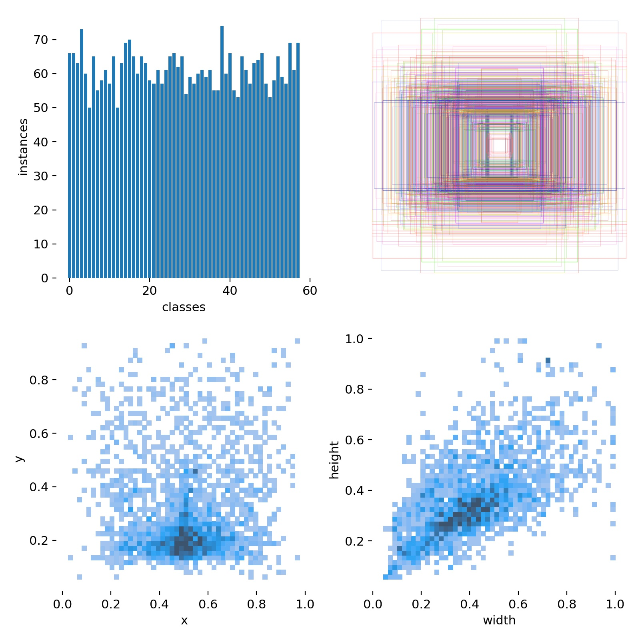

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels.jpg",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

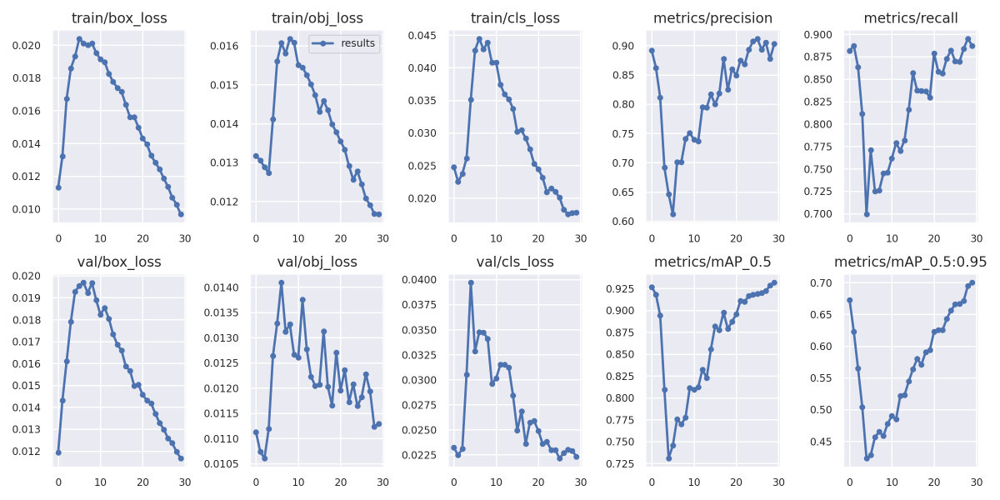

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/results.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.5
                  # save_to_drive=True,
                  # drive_save_path=drive_path_today)
                  )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

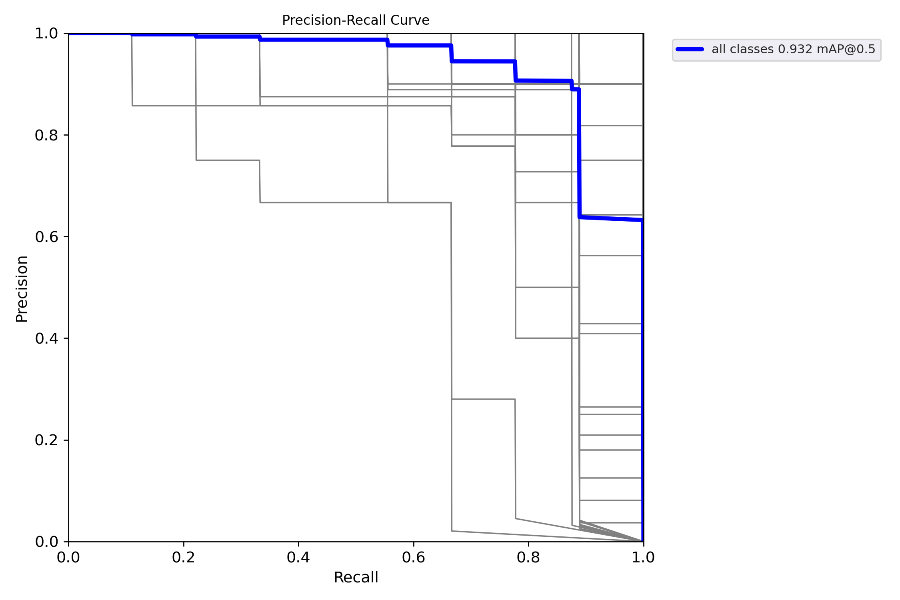

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/PR_curve.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

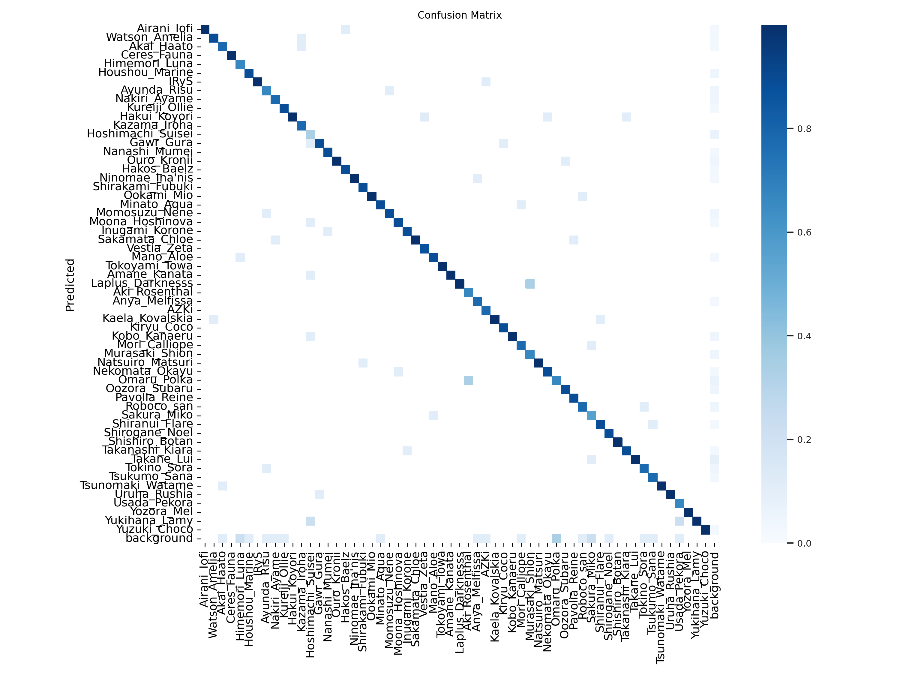

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/confusion_matrix.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.3)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

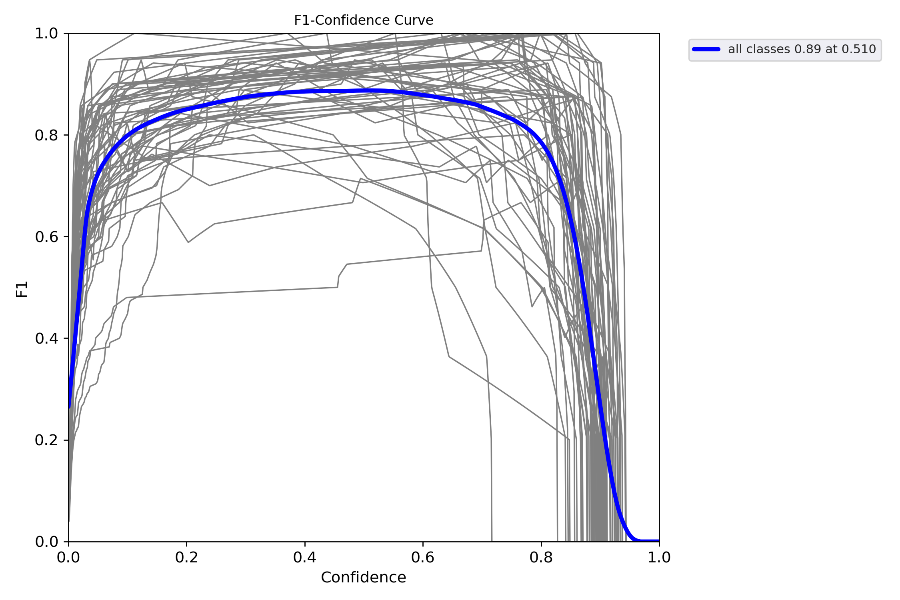

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/F1_curve.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

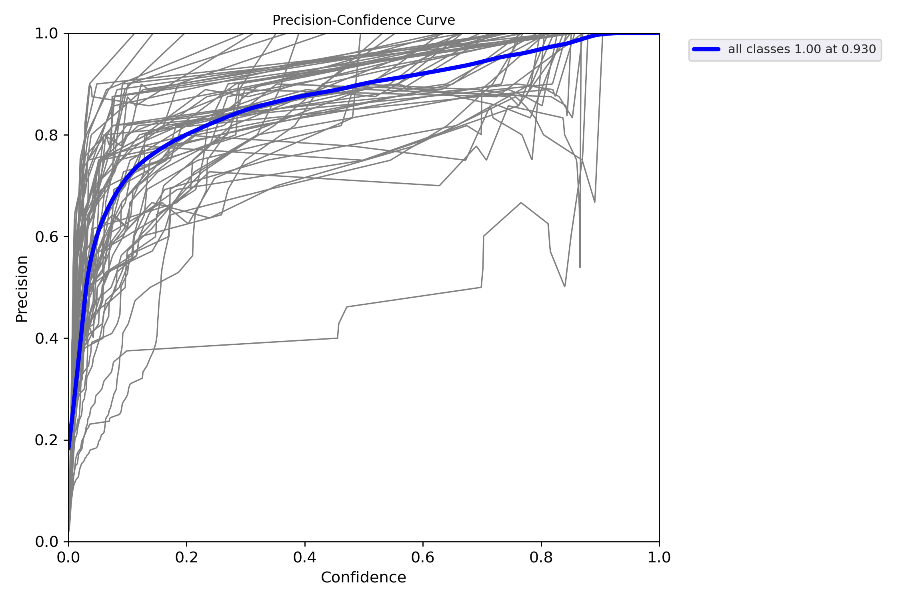

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/P_curve.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

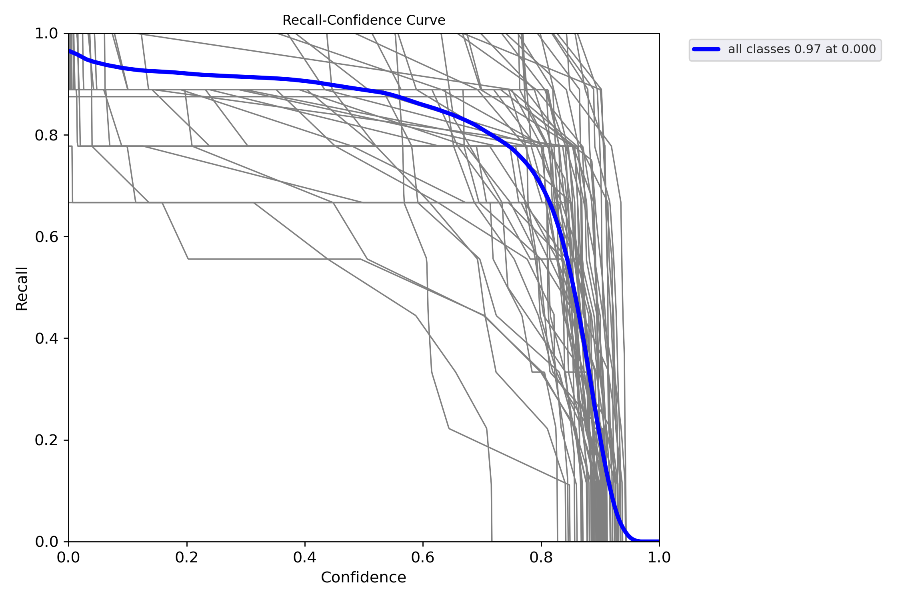

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/R_curve.png",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

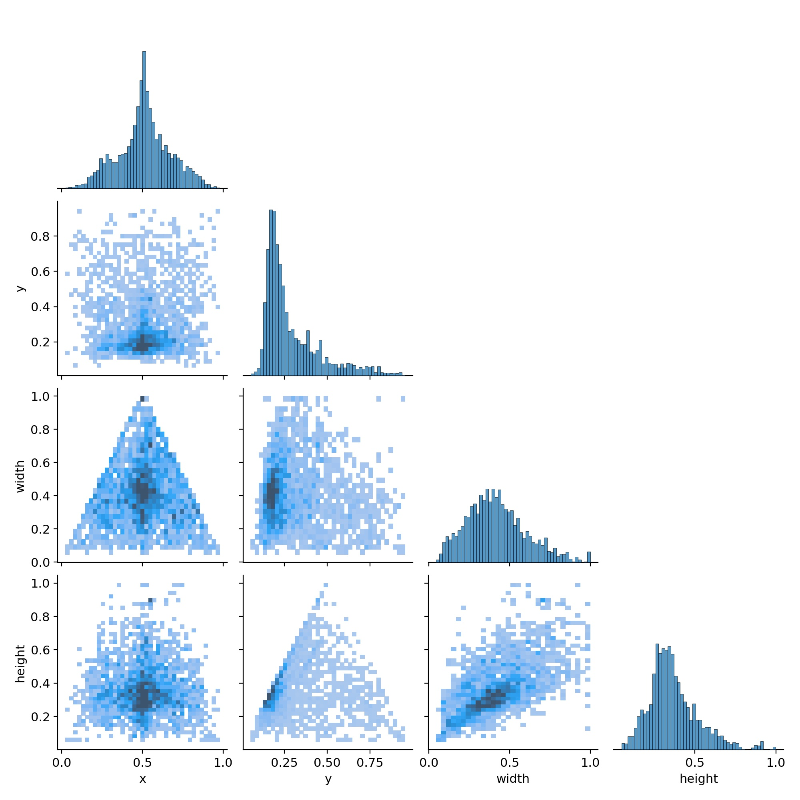

In [ ]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels_correlogram.jpg",
                  pretrained_model=TODAY_PRETRAINED_SAVED_PATH,
                  download_file=True,
                  plot=True,
                  scale=0.4)

In [ ]:
if copy_to_drive:
    !cp -av {local_path_today} '/content/drive/MyDrive'

'/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt' -> '/content/drive/MyDrive/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'
'/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-labels.jpg' -> '/content/drive/MyDrive/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-labels.jpg'
'/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-results.png' -> '/content/drive/MyDrive/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-results.png'
'/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-PR_curve.png' -> '/content/drive/MyDrive/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-PR_curve.png'
'/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-confusion_matrix.png' -> '/content/drive/MyDrive/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification-confusion_ma

# Test Model

detect: weights=['/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://rare-gallery.com/uploads/posts/903659-anime-girls-Hololive-Gawr-Gura-Ninomae-Ina039nis.jpg, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
100% 3.01M/3.01M [00:01<00:00, 2.64MB/s]
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

Fusing layers... 
Model summary: 416 layers, 140720608 parameters, 0 gradients, 209.6 GFLOPs
image 1/1 /content/yolov5/903659-anime-girls-Hololive-Gawr-Gura-Ninomae-Ina039nis.jpg: 704x1280 1 Watson_Amelia, 1 Hoshimachi_Suisei, 1 Gawr_Gura, 1 Ninomae_Ina'nis, 1

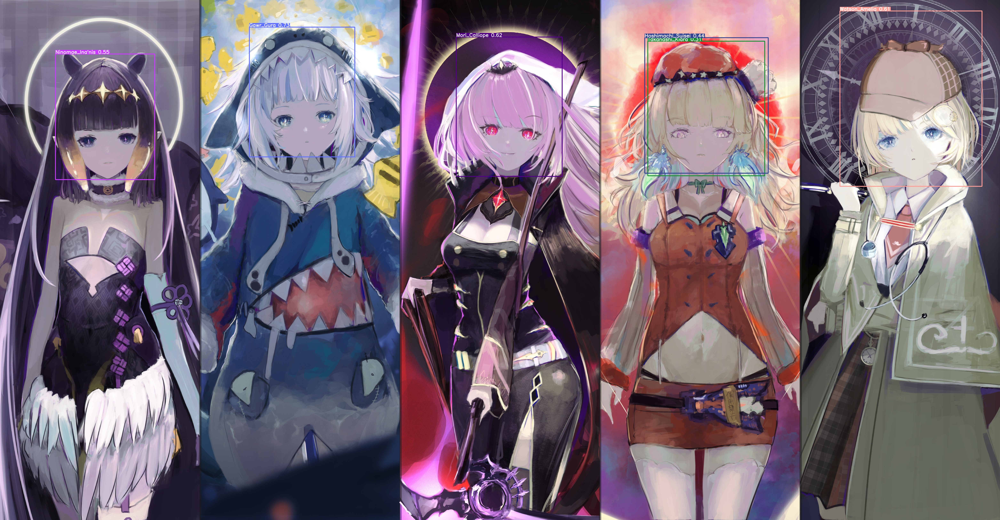

In [ ]:
exp, file_path = gen_image_path(url='https://rare-gallery.com/uploads/posts/903659-anime-girls-Hololive-Gawr-Gura-Ninomae-Ina039nis.jpg',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://rare-gallery.com/uploads/posts/912683-Hololive-Shishiro-Botan-Omaru-Polka-Momosuzu-Nene.jpg, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
100% 579k/579k [00:00<00:00, 828kB/s]
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

Fusing layers... 
Model summary: 416 layers, 140720608 parameters, 0 gradients, 209.6 GFLOPs
image 1/1 /content/yolov5/912683-Hololive-Shishiro-Botan-Omaru-Polka-Momosuzu-Nene.jpg: 768x1280 1 Momosuzu_Nene, 1 Omaru_Polka, 1 Shishiro_Botan, 1 Yukihana_Lamy, 141.3

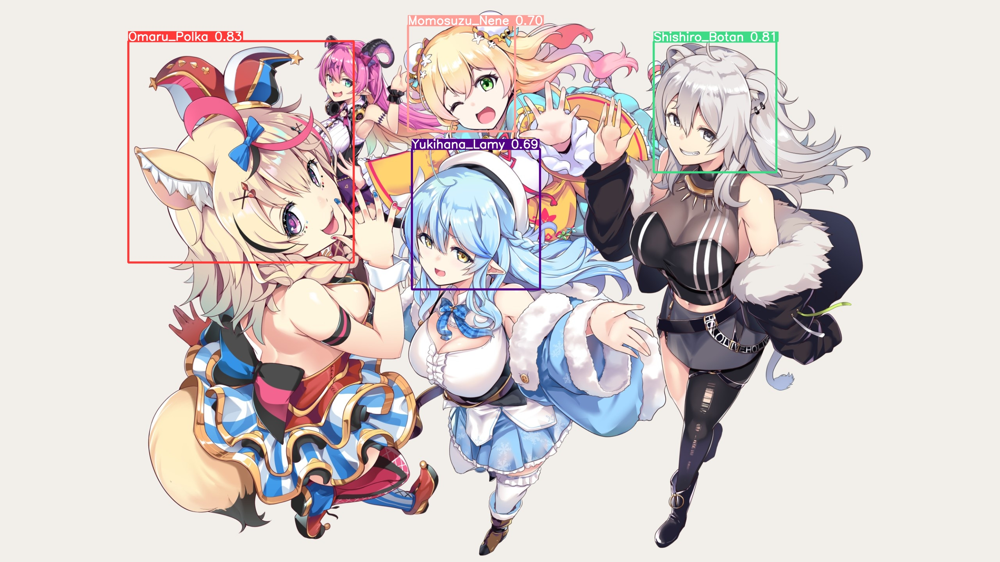

In [ ]:
exp, file_path = gen_image_path(url='https://rare-gallery.com/uploads/posts/912683-Hololive-Shishiro-Botan-Omaru-Polka-Momosuzu-Nene.jpg',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://rare-gallery.com/uploads/posts/951368-anime-anime-girls-digital-art-artwork-2D-portrait.jpg, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
100% 1.98M/1.98M [00:01<00:00, 1.69MB/s]
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

Fusing layers... 
Model summary: 416 layers, 140720608 parameters, 0 gradients, 209.6 GFLOPs
image 1/1 /content/yolov5/951368-anime-anime-girls-digital-art-artwork-2D-portrait.jpg: 960x1280 1 Houshou_Marine, 1 Shiranui_Flare, 1 Shirogane_Noel, 1 Uruha_Rushia,

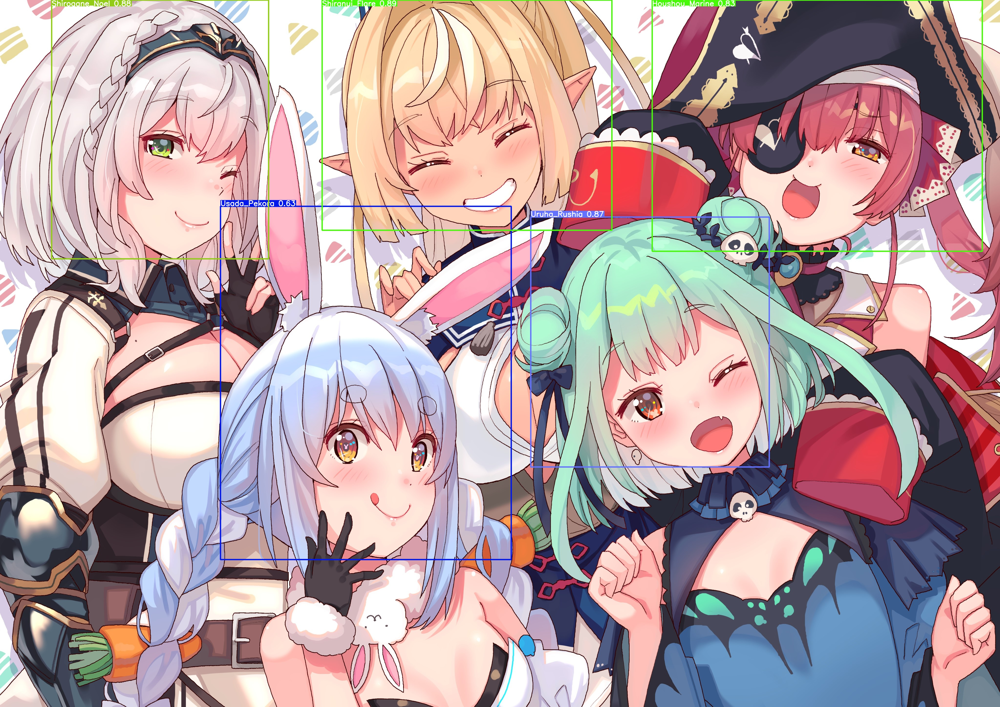

In [ ]:
exp, file_path = gen_image_path(url='https://rare-gallery.com/uploads/posts/951368-anime-anime-girls-digital-art-artwork-2D-portrait.jpg',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://animecorner.me/wp-content/uploads/2022/04/HololiveCouncil.png, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
2.40MB [00:01, 1.69MB/s]
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)

Fusing layers... 
Model summary: 416 layers, 140720608 parameters, 0 gradients, 209.6 GFLOPs
image 1/1 /content/yolov5/HololiveCouncil.png: 768x1280 1 Ceres_Fauna, 1 Nanashi_Mumei, 1 Ouro_Kronii, 1 Hakos_Baelz, 1 Sakamata_Chloe, 1 Tsukumo_Sana, 143.3ms
Speed: 1.2ms pre-process, 143.3ms inference, 1.5ms N

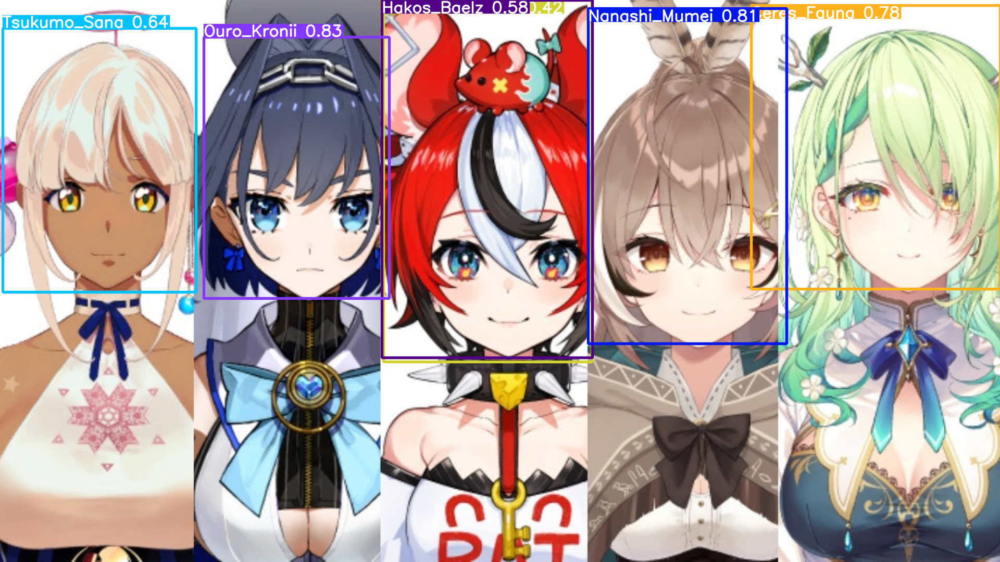

In [ ]:
exp, file_path = gen_image_path(url='https://animecorner.me/wp-content/uploads/2022/04/HololiveCouncil.png',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

In [ ]:
exp, file_path = gen_image_path(url='https://rare-gallery.com/uploads/posts/911531-Mano-Aloe-Momosuzu-Nene-Omaru-Polka-Shishiro-Botan.png',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.10.29/2022.10.29-YOLOv5x6_1280-Hololive_Waifu_Classification.pt'], source=https://rare-gallery.com/uploads/posts/911531-Mano-Aloe-Momosuzu-Nene-Omaru-Polka-Shishiro-Botan.png, data=data/coco128.yaml, imgsz=[1280, 1280], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
100% 22.0M/22.0M [00:02<00:00, 7.92MB/s]
YOLOv5 🚀 v6.2-216-g6e544d5 Python-3.7.15 torch-1.12.1+cu113 CUDA:0 (Tesla T4, 15110MiB)



In [ ]:
exp, file_path = gen_image_path(url='https://rare-gallery.com/mocahbig/438902-Mano-Aloe-Momosuzu-Nene-Omaru-Polka-Shishiro-Botan.png',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

In [ ]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FT6fewfagAALPi1.jpg',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

In [ ]:
exp, file_path = gen_image_path(url='https://pbs.twimg.com/media/FVoeae6akAEG-23.jpg',
                                exp=exp, 
                                pretrained_model=TODAY_PRETRAINED_SAVED_PATH)
Image(filename=file_path, width=600)

In [ ]:
# exp, file_path = gen_image_path(url='',
#                                 exp=exp, 
#                                 pretrained_model=pretrained_model)
# Image(filename=file_path, width=600)

In [ ]:
# exp, file_path = gen_image_path(url='',
#                                 exp=exp, 
#                                 pretrained_model=pretrained_model)
# Image(filename=file_path, width=600)

# 16. Sleeping

In [ ]:
# os.path.exists('/content/drive/MyDrive/yolov5.zip')

In [ ]:
_ = Sleep().sleep()

Sleeping... 04h43s

In [ ]:
# import cv2
# import numpy as np

# class Augmentation():
#     def __init__(self, image_path, label_path):
#         self.image_path = image_path
#         self.label_path = label_path
#         self.image = np.asarray(cv2.imread(self.image_path))

#     def copy_label_content(self, new_label_path):
#         lines = open(self.label_path, "r").readlines()
#         with open(new_label_path, "w") as f:
#             for line in lines:
#                 f.write(line)

#     def new_augemented_path(self, path, new_part):
#         return f'{".".join(path.split(".")[:-1])}-{new_part}.{path.split(".")[-1]}'
    
#     def fix(self, num):
#         if int(num) - num == 0: num = int(num)
#         return num

#     def save(self, image, portion, part):
#         cv2.imwrite(self.new_augemented_path(path=self.image_path,
#                                                 new_part=f"{part}_{portion}"), image)
#         self.copy_label_content(new_label_path=self.new_augemented_path(path=self.label_path,
#                                                                         new_part=f"{part}_{portion}"))

# class RandomValuedImpulseNoise(Augmentation):
#     def __init__(self, image_path, label_path, portion=None):
#         super().__init__(image_path, label_path)
#         if portion == None:
#             self.portion = round(np.random.uniform(low=0.001, high=0.1), 3)
#         else:
#             assert 0 <= portion <= 0.1, "Please use portion within [0, 0.1]"
#             self.portion = portion
#         self.thres = 1 - self.portion

#     def execute(self, save=True):
#         mask = np.random.rand(*self.image.shape[:2])
#         mask = np.concatenate([mask, mask, mask]).reshape(*mask.shape, 3)
#         self.image = np.where(self.portion*2>mask, np.random.randint(low=0, high=255, size=1, dtype=int), self.image) 
#         # self.image = np.where(self.portion>mask, 0, self.image)
#         # self.image = np.where(self.thres<mask, 255, self.image)
#         if save: self.save(image=self.image, 
#                            portion=self.portion*2, 
#                            part=type(self).__name__)

# class RandomSaltAndPepper(Augmentation):
#     def __init__(self, image_path, label_path, portion=None):
#         super().__init__(image_path, label_path)
#         if portion == None:
#             self.portion = round(np.random.uniform(low=0.001, high=0.1), 3)
#         else:
#             assert 0 <= portion <= 0.1, "Please use portion within [0, 0.1]"
#             self.portion = portion
#         self.thres = 1 - self.portion

#     def execute(self, save=True):
#         mask = np.random.rand(self.image.shape[0], self.image.shape[1])
#         mask = np.array([mask.T, mask.T, mask.T]).T
#         self.image = np.where(self.portion>mask, 0, self.image) 
#         self.image = np.where(self.thres<mask, 255, self.image)
#         if save: self.save(image=self.image, 
#                            portion=self.portion*2, 
#                            part=type(self).__name__)

# class RandomBrightness(Augmentation):
#     def __init__(self, image_path, label_path, level=None):
#         super().__init__(image_path, label_path)
#         if level == None:
#             self.level = round(np.random.uniform(low=0.1, high=2), 3)
#         else:
#             assert 0.1 <= level <= 2, "Please use level within [0.1, 1), (1, 2]"
#             self.level = round(float(level), 3)
        
#         while self.level == 1:
#             self.level = round(np.random.uniform(low=0.1, high=2), 3)
#     def execute(self, save=True):
#         self.image = np.clip(a=(self.image * self.level).astype(int),
#                              a_min=0,
#                              a_max=255)
#         if save: self.save(image=self.image, 
#                            portion=self.level, 
#                            part=type(self).__name__)

# RandomBrightness(image_path='/content/Pixiv-83072275_p0.jpg', label_path='/content/Pixiv-83072275_p0.txt', level=0.800).execute()

In [ ]:
# import cv2
# import numpy as np

# class RandomBrightness():
#     def __init__(self, image_path, label_path, level=None):
#         self.image_path = image_path
#         self.label_path = label_path
#         if level == None:
#             self.level = round(np.random.uniform(low=0.1, high=2), 1)
#         else:
#             assert 0.1 <= level <= 2, "Please use level within [0.1, 2]"
#             self.level = round(float(level), 1)
#     def copy_label_content(self, new_label_path):
#         lines = open(self.label_path, "r").readlines()
#         with open(new_label_path, "w") as f:
#             for line in lines:
#                 f.write(line)

#     def new_augemented_path(self, path, new_part):
#         return f'{".".join(path.split(".")[:-1])}-{new_part}.{path.split(".")[-1]}'
    
#     def fix(self, num):
#         if int(num) - num == 0: num = int(num)
#         return num

#     def main(self, save=True):
#         image = np.clip(a=(np.asarray(cv2.imread(self.image_path)) * self.level).astype(int),
#                         a_min=0,
#                         a_max=255)
#         if save:
#             cv2.imwrite(self.new_augemented_path(path=self.image_path,
#                                                  new_part=f"Brightness_{self.fix(self.level)}"), image)
#             self.copy_label_content(new_label_path=self.new_augemented_path(path=self.label_path,
#                                                                             new_part=f"Brightness_{self.fix(self.level)}"))
# RandomBrightness(image_path='/content/Pixiv-83072275_p0.jpg',
#                  label_path='/content/Pixiv-83072275_p0.txt',
#                  level=2).main()

In [ ]:
mask = np.random.rand(3, 5)
mask1 = np.concatenate([mask, mask, mask]).reshape(*mask.shape, 3)
# mask, mask1
print()